<a href="https://colab.research.google.com/github/Sashanka2001/pre-enhancement--Google-Colab/blob/main/Google_Col_pre_enhancement_facial_recoverability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#Cell 1: Environment & Dependency Setup
# Install core dependencies and Python 3.13-compatible builds for rembg & OpenCV
!pip install -q mediapipe pandas matplotlib scikit-image tqdm datasets
!pip install -U --prefer-binary "rembg[cpu]" onnxruntime pillow opencv-python-headless

In [15]:
#Directory Setup & Google Drive Mounting
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Project paths on Google Drive
DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
DIR_ORIGINAL = os.path.join(DRIVE_PROJECT, "dataset/original")
DIR_CROPPED = os.path.join(DRIVE_PROJECT, "dataset/cropped")
DIR_DEGRADED = os.path.join(DRIVE_PROJECT, "dataset/degraded")
DIR_METADATA = os.path.join(DRIVE_PROJECT, "dataset/metadata")

# 3. List of degradation subfolders
degraded_types = [
    "blur",
    "noise",
    "brightness",
    "contrast",
    "jpeg",
    "low_resolution",
    "combined"
]

# 4. Create local directory structure
local_directories = [
    "dataset/original",
    "dataset/cropped",
    "dataset/metadata",
    "graphs"
] + [f"dataset/degraded/{sub}" for sub in degraded_types]

for folder in local_directories:
    os.makedirs(folder, exist_ok=True)

# 5. Create Google Drive directory structure
drive_directories = [
    DIR_ORIGINAL,
    DIR_CROPPED,
    DIR_METADATA
] + [os.path.join(DIR_DEGRADED, sub) for sub in degraded_types]

for folder in drive_directories:
    os.makedirs(folder, exist_ok=True)

print("Workspace and Google Drive paths (including all degraded subfolders) initialized successfully!")

Mounted at /content/drive
✅ Workspace and Google Drive paths (including all degraded subfolders) initialized successfully!


In [16]:
#Cell 3: Step 1 — Download 500 Original Faces Directly to Drive
# Step 1: Download Original Faces Directly to Google Drive (Preserves Directory Structure)

import cv2
import shutil
from tqdm import tqdm

def download_ffhq_straight_to_drive(output_dir: str = DIR_ORIGINAL, target_count: int = 500):
    existing_files = [f for f in os.listdir(output_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if len(existing_files) >= target_count:
        print(f"Google Drive directory '{output_dir}' already contains {len(existing_files)} original faces.")
        print("Skipping download process!")
        return

    !pip install -q kagglehub
    import kagglehub

    print("Downloading high-resolution FFHQ dataset from Kaggle...")
    kaggle_path = kagglehub.dataset_download("arnaud58/flickrfaceshq-dataset-ffhq")

    image_files = []
    for root, _, files in os.walk(kaggle_path):
        for file in sorted(files):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_files.append(os.path.join(root, file))

    count_to_save = min(target_count, len(image_files))
    print(f"Saving top {count_to_save} FFHQ faces directly to Google Drive...")

    for idx in tqdm(range(count_to_save), desc="Saving to Google Drive"):
        src = image_files[idx]
        img = cv2.imread(src)
        if img is not None:
            dest = os.path.join(output_dir, f"face_{idx + 1:04d}.png")
            cv2.imwrite(dest, img)

    # Clean temporary Kaggle download cache to keep Colab disk clear
    if os.path.exists("/root/.cache/kagglehub"):
        shutil.rmtree("/root/.cache/kagglehub")
    if os.path.exists("/kaggle/input"):
        shutil.rmtree("/kaggle/input")

    print(f"\nSuccess! All images saved into Google Drive. Local folder structure preserved.")

download_ffhq_straight_to_drive(output_dir=DIR_ORIGINAL, target_count=500)

Google Drive directory '/content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/original' already contains 500 original faces.
Skipping download process!


In [17]:
# Cell 4: Verify Saved FFHQ Images in Drive
# Verify Image Count & Structural Integrity directly from Google Drive
files = sorted([f for f in os.listdir(DIR_ORIGINAL) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

valid_count = 0
sample_specs = []

for filename in files:
    path = os.path.join(DIR_ORIGINAL, filename)
    img = cv2.imread(path)
    if img is not None:
        valid_count += 1
        if len(sample_specs) < 3:
            sample_specs.append((filename, img.shape))

print(f"Total Valid FFHQ Images Verified in Google Drive: {valid_count}/{len(files)}")
print("\nSample File Specifications:")
for name, shape in sample_specs:
    print(f" - {name}: {shape[1]}x{shape[0]} pixels, {shape[2]} channels (BGR)")

Total Valid FFHQ Images Verified in Google Drive: 500/500

Sample File Specifications:
 - face_0001.png: 512x512 pixels, 3 channels (BGR)
 - face_0002.png: 512x512 pixels, 3 channels (BGR)
 - face_0003.png: 512x512 pixels, 3 channels (BGR)


In [18]:
#Cell 5: Step 2 — Background Removal & Facial Segmentation
# Step 2: Background Removal & Facial Segmentation (Google Drive Auto-Resume)

from PIL import Image
from rembg import remove
from tqdm import tqdm

def segment_faces_directly_to_drive(input_dir: str = DIR_ORIGINAL,
                                    output_dir: str = DIR_CROPPED,
                                    background_color: tuple = (255, 255, 255),
                                    max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)

    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)])

    if max_images is not None:
        image_files = image_files[:max_images]

    processed_count = 0
    skipped_count = 0

    for filename in tqdm(image_files, desc="Removing Backgrounds"):
        src_path = os.path.join(input_dir, filename)
        output_filename = os.path.splitext(filename)[0] + ".png"
        dest_path = os.path.join(output_dir, output_filename)

        # Skip files already present in Google Drive
        if os.path.exists(dest_path):
            skipped_count += 1
            continue

        try:
            input_image = Image.open(src_path)
            segmented_image = remove(input_image)

            if background_color is not None:
                canvas = Image.new("RGBA", segmented_image.size, background_color + (255,))
                final_image = Image.alpha_composite(canvas, segmented_image).convert("RGB")
            else:
                final_image = segmented_image

            final_image.save(dest_path)
            processed_count += 1

        except Exception as e:
            print(f"Error processing {filename}: {e}")

    print(f"\nComplete! Processed {processed_count} new images. Skipped {skipped_count} existing images.")

# Execute background removal for 100 images (Change max_images=100 to max_images=None for all 500)
segment_faces_directly_to_drive(input_dir=DIR_ORIGINAL,
                                output_dir=DIR_CROPPED,
                                background_color=(255, 255, 255),
                                max_images=100)

Removing Backgrounds: 100%|██████████| 100/100 [00:00<00:00, 2415.31it/s]


Complete! Processed 0 new images. Skipped 100 existing images.


In [19]:
# Setup & Directory Paths
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

DIR_DEGRADED = os.path.join(DRIVE_PROJECT, "dataset/degraded")
DIR_METADATA = os.path.join(DRIVE_PROJECT, "dataset/metadata")

In [21]:
# Degradation 1: Gaussian Blur

import os
import cv2
from tqdm import tqdm

def generate_blur_degradations(cropped_dir: str = DIR_CROPPED,
                               output_dir: str = os.path.join(DIR_DEGRADED, "blur"),
                               max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])
    if max_images is not None:
        image_files = image_files[:max_images]

    records = []
    for filename in tqdm(image_files, desc="1/7 Applying Gaussian Blur"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for sig in [1, 2, 3, 5, 7]:
            deg_filename = f"{base_name}_blur_s{sig}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                kernel_size = 2 * int(3 * sig) + 1
                blurred_img = cv2.GaussianBlur(img, (kernel_size, kernel_size), sig)
                cv2.imwrite(save_path, blurred_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Gaussian Blur",
                "severity_parameter": "sigma",
                "parameter_value": float(sig),
                "drive_path": save_path
            })
    return records

blur_records = generate_blur_degradations(max_images=100)

1/7 Applying Gaussian Blur: 100%|██████████| 100/100 [00:20<00:00,  4.96it/s]


In [22]:
# Degradation 2: Gaussian Noise

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_noise_degradations(cropped_dir: str = DIR_CROPPED,
                                output_dir: str = os.path.join(DIR_DEGRADED, "noise"),
                                max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])
    if max_images is not None:
        image_files = image_files[:max_images]

    records = []
    for filename in tqdm(image_files, desc="2/7 Applying Gaussian Noise"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for std in [5, 10, 15, 20, 30]:
            deg_filename = f"{base_name}_noise_s{std}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                noise = np.random.normal(0, std, img.shape).astype(np.float32)
                noisy_img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
                cv2.imwrite(save_path, noisy_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Gaussian Noise",
                "severity_parameter": "std_dev",
                "parameter_value": float(std),
                "drive_path": save_path
            })
    return records

noise_records = generate_noise_degradations(max_images=100)

2/7 Applying Gaussian Noise: 100%|██████████| 100/100 [00:35<00:00,  2.79it/s]


In [23]:
# Degradation 3: Brightness Scaling

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_brightness_degradations(cropped_dir: str = DIR_CROPPED,
                                     output_dir: str = os.path.join(DIR_DEGRADED, "brightness"),
                                     max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])
    if max_images is not None:
        image_files = image_files[:max_images]

    records = []
    for filename in tqdm(image_files, desc="3/7 Applying Brightness Scaling"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for alpha in [0.6, 0.8, 1.2, 1.4]:
            deg_filename = f"{base_name}_bright_a{alpha}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                bright_img = np.clip(img.astype(np.float32) * alpha, 0, 255).astype(np.uint8)
                cv2.imwrite(save_path, bright_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Brightness",
                "severity_parameter": "alpha",
                "parameter_value": float(alpha),
                "drive_path": save_path
            })
    return records

bright_records = generate_brightness_degradations(max_images=100)

3/7 Applying Brightness Scaling: 100%|██████████| 100/100 [00:13<00:00,  7.45it/s]


In [24]:
# Degradation 4: Contrast Adjustment

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_contrast_degradations(cropped_dir: str = DIR_CROPPED,
                                   output_dir: str = os.path.join(DIR_DEGRADED, "contrast"),
                                   max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])
    if max_images is not None:
        image_files = image_files[:max_images]

    records = []
    for filename in tqdm(image_files, desc="4/7 Applying Contrast Adjustment"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)
        mean_val = np.mean(img)

        for beta in [0.6, 0.8, 1.2, 1.5]:
            deg_filename = f"{base_name}_contrast_b{beta}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                contrast_img = np.clip((img.astype(np.float32) - mean_val) * beta + mean_val, 0, 255).astype(np.uint8)
                cv2.imwrite(save_path, contrast_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Contrast",
                "severity_parameter": "beta",
                "parameter_value": float(beta),
                "drive_path": save_path
            })
    return records

contrast_records = generate_contrast_degradations(max_images=100)

4/7 Applying Contrast Adjustment: 100%|██████████| 100/100 [00:14<00:00,  6.81it/s]


In [25]:
# Degradation 5: JPEG Compression

import os
import cv2
from tqdm import tqdm

def generate_jpeg_degradations(cropped_dir: str = DIR_CROPPED,
                               output_dir: str = os.path.join(DIR_DEGRADED, "jpeg"),
                               max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])
    if max_images is not None:
        image_files = image_files[:max_images]

    records = []
    for filename in tqdm(image_files, desc="5/7 Applying JPEG Compression"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)

        for q in [95, 80, 60, 40, 20]:
            deg_filename = f"{base_name}_jpeg_q{q}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                _, encoded_img = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), q])
                jpeg_img = cv2.imdecode(encoded_img, 1)
                cv2.imwrite(save_path, jpeg_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "JPEG Compression",
                "severity_parameter": "quality",
                "parameter_value": float(q),
                "drive_path": save_path
            })
    return records

jpeg_records = generate_jpeg_degradations(max_images=100)

5/7 Applying JPEG Compression: 100%|██████████| 100/100 [00:17<00:00,  5.85it/s]


In [26]:
# Degradation 6: Low Resolution Downsampling

import os
import cv2
from tqdm import tqdm

def generate_lowres_degradations(cropped_dir: str = DIR_CROPPED,
                                 output_dir: str = os.path.join(DIR_DEGRADED, "low_resolution"),
                                 max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])
    if max_images is not None:
        image_files = image_files[:max_images]

    records = []
    for filename in tqdm(image_files, desc="6/7 Applying Low Resolution Downsampling"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        base_name, ext = os.path.splitext(filename)
        orig_h, orig_w, _ = img.shape

        for dim in [256, 128, 64]:
            deg_filename = f"{base_name}_lowres_d{dim}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                downscaled = cv2.resize(img, (dim, dim), interpolation=cv2.INTER_AREA)
                upscaled = cv2.resize(downscaled, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
                cv2.imwrite(save_path, upscaled)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": "Low Resolution",
                "severity_parameter": "dimension",
                "parameter_value": float(dim),
                "drive_path": save_path
            })
    return records

lowres_records = generate_lowres_degradations(max_images=100)

6/7 Applying Low Resolution Downsampling: 100%|██████████| 100/100 [00:07<00:00, 14.13it/s]


In [27]:
# Degradation 7: Combined Multi-Factor Preset Degradations

import os
import cv2
import numpy as np
from tqdm import tqdm

def generate_combined_degradations(cropped_dir: str = DIR_CROPPED,
                                   output_dir: str = os.path.join(DIR_DEGRADED, "combined"),
                                   max_images: int = 100):
    os.makedirs(output_dir, exist_ok=True)
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(cropped_dir) if f.lower().endswith(valid_extensions)])
    if max_images is not None:
        image_files = image_files[:max_images]

    combinations = [
        {"suffix": "combo_blur_noise", "type": "Blur + Noise", "params": {"sigma": 3, "std_dev": 15}, "blur_sig": 3, "noise_std": 15, "jpeg_q": None, "low_res": None},
        {"suffix": "combo_blur_jpeg", "type": "Blur + JPEG", "params": {"sigma": 3, "quality": 40}, "blur_sig": 3, "noise_std": None, "jpeg_q": 40, "low_res": None},
        {"suffix": "combo_noise_jpeg", "type": "Noise + JPEG", "params": {"std_dev": 15, "quality": 40}, "blur_sig": None, "noise_std": 15, "jpeg_q": 40, "low_res": None},
        {"suffix": "combo_lowres_blur", "type": "LowRes + Blur", "params": {"dimension": 128, "sigma": 3}, "blur_sig": 3, "noise_std": None, "jpeg_q": None, "low_res": 128},
        {"suffix": "combo_lowres_noise", "type": "LowRes + Noise", "params": {"dimension": 128, "std_dev": 15}, "blur_sig": None, "noise_std": 15, "jpeg_q": None, "low_res": 128},
        {"suffix": "combo_heavy_multifactor", "type": "Severe Multi-Factor", "params": {"sigma": 3, "std_dev": 15, "dimension": 128, "quality": 40}, "blur_sig": 3, "noise_std": 15, "jpeg_q": 40, "low_res": 128}
    ]

    records = []
    for filename in tqdm(image_files, desc="7/7 Applying Combined Degradations"):
        img_path = os.path.join(cropped_dir, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue

        base_name, ext = os.path.splitext(filename)
        orig_h, orig_w, _ = img.shape

        for combo in combinations:
            deg_filename = f"{base_name}_{combo['suffix']}{ext}"
            save_path = os.path.join(output_dir, deg_filename)

            if not os.path.exists(save_path):
                processed_img = img.copy()

                if combo["low_res"] is not None:
                    dim = combo["low_res"]
                    downscaled = cv2.resize(processed_img, (dim, dim), interpolation=cv2.INTER_AREA)
                    processed_img = cv2.resize(downscaled, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

                if combo["blur_sig"] is not None:
                    sig = combo["blur_sig"]
                    kernel_size = 2 * int(3 * sig) + 1
                    processed_img = cv2.GaussianBlur(processed_img, (kernel_size, kernel_size), sig)

                if combo["noise_std"] is not None:
                    std = combo["noise_std"]
                    noise = np.random.normal(0, std, processed_img.shape).astype(np.float32)
                    processed_img = np.clip(processed_img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

                if combo["jpeg_q"] is not None:
                    q = combo["jpeg_q"]
                    _, encoded_img = cv2.imencode('.jpg', processed_img, [int(cv2.IMWRITE_JPEG_QUALITY), q])
                    processed_img = cv2.imdecode(encoded_img, 1)

                cv2.imwrite(save_path, processed_img)

            records.append({
                "original_filename": filename,
                "degraded_filename": deg_filename,
                "degradation_type": combo["type"],
                "severity_parameter": "combined_preset",
                "parameter_value": str(combo["params"]),
                "drive_path": save_path
            })

    return records

combined_records = generate_combined_degradations(max_images=100)

7/7 Applying Combined Degradations: 100%|██████████| 100/100 [00:36<00:00,  2.72it/s]


In [28]:
# Master Metadata Saver: Saves images to Drive, CSV & Graphs to local Colab storage

import os
import pandas as pd

# Combine records from all 7 degradation functions
all_records = (
    blur_records +
    noise_records +
    bright_records +
    contrast_records +
    jpeg_records +
    lowres_records +
    combined_records
)

df = pd.DataFrame(all_records)

# Local Colab paths for metadata CSV and graphs
LOCAL_METADATA_DIR = "dataset/metadata"
LOCAL_GRAPHS_DIR = "graphs"

os.makedirs(LOCAL_METADATA_DIR, exist_ok=True)
os.makedirs(LOCAL_GRAPHS_DIR, exist_ok=True)

# Save metadata.csv locally to Colab disk
local_csv_path = os.path.join(LOCAL_METADATA_DIR, "metadata.csv")
df.to_csv(local_csv_path, index=False)

print("✅ All 7 degradation modules complete!")
print(f"📸 Images saved to Google Drive: '{DIR_DEGRADED}'")
print(f"📊 CSV file saved locally in Colab: '{local_csv_path}'")
print(f"📈 Graph directory initialized locally in Colab: '{LOCAL_GRAPHS_DIR}/'")

✅ All 7 degradation modules complete!
📸 Images saved to Google Drive: '/content/drive/MyDrive/pre_enhancement_facial_recoverability/dataset/degraded'
📊 CSV file saved locally in Colab: 'dataset/metadata/metadata.csv'
📈 Graph directory initialized locally in Colab: 'graphs/'


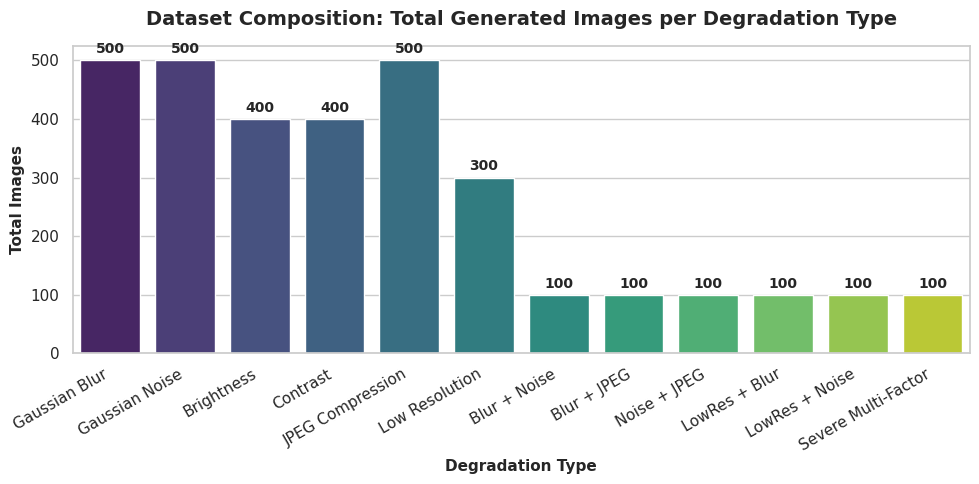

Distribution graph displayed and saved to 'graphs/degradation_distribution.png'


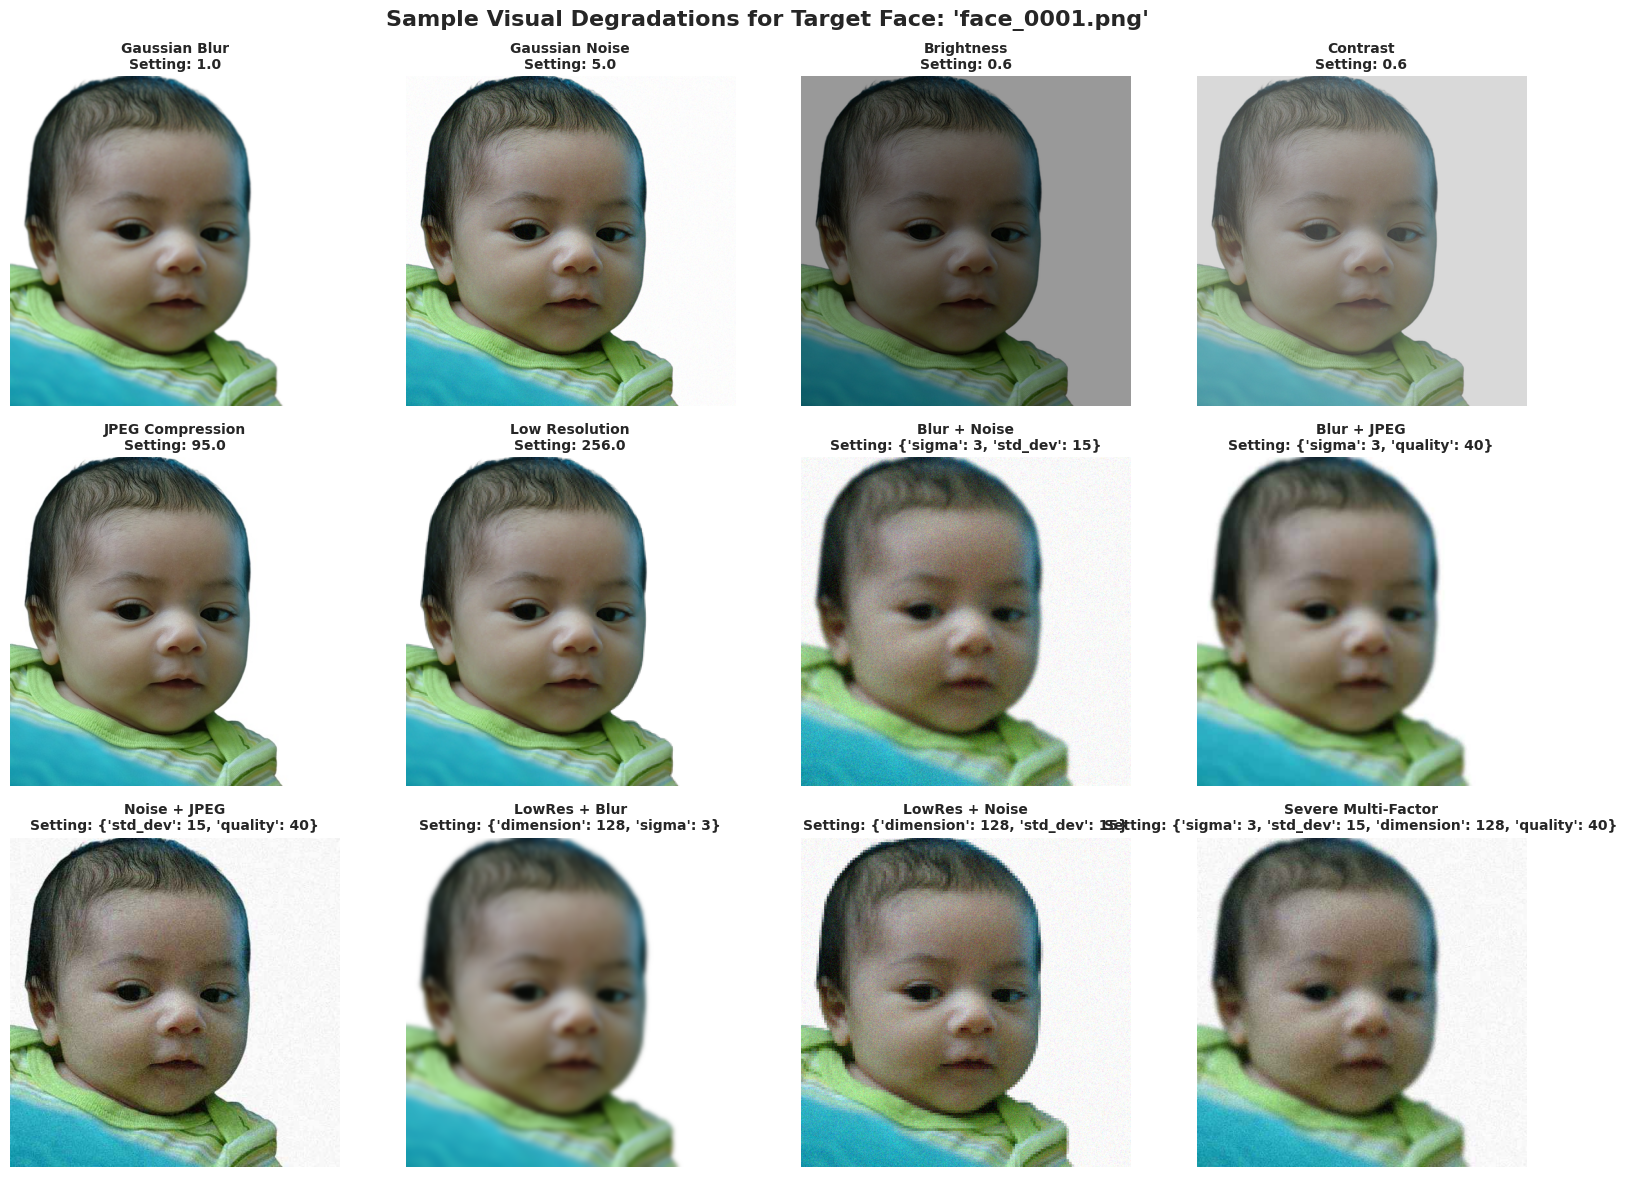

 Visual sample comparison grid displayed and saved to 'graphs/sample_degradations_grid.png'


In [29]:
# Step: Generate, Display, and Save Dataset Graphs

import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure paths and metadata are available
LOCAL_METADATA_DIR = "dataset/metadata"
LOCAL_GRAPHS_DIR = "graphs"
os.makedirs(LOCAL_GRAPHS_DIR, exist_ok=True)

csv_path = os.path.join(LOCAL_METADATA_DIR, "metadata.csv")

if 'df' not in locals() or df.empty:
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError(f"Could not find '{csv_path}'. Please run the metadata saver script first.")

# Graph 1: Total Image Count per Degradation Category
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x="degradation_type",
    hue="degradation_type",
    palette="viridis",
    legend=False
)
plt.title("Dataset Composition: Total Generated Images per Degradation Type", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Degradation Type", fontsize=11, fontweight='bold')
plt.ylabel("Total Images", fontsize=11, fontweight='bold')
plt.xticks(rotation=30, ha="right")

# Add numerical values above each bar
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(f'{height}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
chart_path = os.path.join(LOCAL_GRAPHS_DIR, "degradation_distribution.png")
plt.savefig(chart_path, dpi=300)
plt.show()  # Renders plot in Colab

print(f"Distribution graph displayed and saved to '{chart_path}'")

# Graph 2: Visual Comparison Grid of a Sample Face Across Degradation Types
sample_face = df["original_filename"].iloc[0]
sample_df = df[df["original_filename"] == sample_face].drop_duplicates(subset=["degradation_type"])

cols = 4
rows = (len(sample_df) + cols - 1) // cols

plt.figure(figsize=(16, 4 * rows))
plt.suptitle(f"Sample Visual Degradations for Target Face: '{sample_face}'", fontsize=16, fontweight='bold', y=0.98)

for idx, (_, row) in enumerate(sample_df.iterrows()):
    img_path = row["drive_path"]
    img = cv2.imread(img_path)

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img_rgb)
        plt.title(f"{row['degradation_type']}\nSetting: {row['parameter_value']}", fontsize=10, fontweight='bold')
        plt.axis("off")

plt.tight_layout()
grid_path = os.path.join(LOCAL_GRAPHS_DIR, "sample_degradations_grid.png")
plt.savefig(grid_path, dpi=300)
plt.show()  # Renders sample grid in Colab

print(f" Visual sample comparison grid displayed and saved to '{grid_path}'")